This is a pipeline constituting an RNN, LSTM, and Transformer which will train on the same uniformly processed dataset of historical S&P 500 data, which will be processed and prepared to be sent into the models, which will then be initially trained. Following this, they will have hyperparemeter tuning performed on them, and finally metrics and graphs will show the final results.

# 1. Universal Installs/Imports/Constants

# Install necessary libraries

In [ ]:
!pip install -q yfinance optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 11.0 MB/s eta 0:00:00


# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import json
import time
from copy import deepcopy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import yfinance as yf
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import os
from google.colab import drive

In [ ]:
import sys
import torch
import sklearn
import optuna
import numpy as np
import pandas as pd
import yfinance as yf

print(
    f"PyTorch [{torch.__version__}], scikit-learn [{sklearn.__version__}], "
    f"Optuna [{optuna.__version__}], NumPy [{np.__version__}], "
    f"pandas [{pd.__version__}], and yfinance [{yf.__version__}] "
    f"under Python [{sys.version.split()[0]}]."
)


PyTorch [2.11.0+cu128], scikit-learn [1.6.1], Optuna [4.9.0], NumPy [2.0.2], pandas [2.2.2], and yfinance [0.2.66] under Python [3.12.13].


In [ ]:
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/SP500_paper/'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


# Warnings, Seed, GPU Usage, and Hyperparameters

In [ ]:
# Warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# Seed Setting for Reproducability
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set to GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Hyperparameters
WINDOW_SIZE = 300
BATCH_SIZE = 32
NUM_EPOCHS = 60
INPUT_SIZE = 8

Device: cuda
GPU: Tesla T4


These steps installed, imported, and set constant variables necessary for the following pipeline.

# 2. Download and Preparation/Split/Feature Extraction of Dataset (yfinance historical S&P 500 Data)

# Download the Historical S&P 500 dataset using yfinance

source: https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html#yfinance.download

In [ ]:
# Download and view dataset

S_P_Dataset = yf.download("^GSPC", start="2000-01-01", end="2026-4-1", progress=False)

S_P_Dataset.dropna()

print(f"Dataset shape: {S_P_Dataset.shape}")
print(f"Date range: {S_P_Dataset.index[0].date()} to {S_P_Dataset.index[-1].date()}")
S_P_Dataset.tail(5)

# S_P_Dataset['Close'].tail(5)

Dataset shape: (6600, 5)
Date range: 2000-01-03 to 2026-03-31


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2026-03-25,6591.899902,6633.939941,6568.410156,6598.350098,4936720000
2026-03-26,6477.160156,6573.220215,6473.790039,6555.859863,4845560000
2026-03-27,6368.850098,6453.890137,6356.080078,6453.890137,5303490000
2026-03-30,6343.720215,6427.310059,6316.910156,6403.370117,5458640000
2026-03-31,6528.520020,6539.049805,6395.879883,6395.879883,6396100000


In [ ]:
df = S_P_Dataset.copy()

df['Target'] = (
    df['Close'].shift(-1) > df['Close']
).astype(int)

# Remove final row (no next day available)
df = df[:-1]

# Count classes
class_counts = df['Target'].value_counts().sort_index()

down_days = class_counts[0]
up_days = class_counts[1]

total = len(df)

print("Class Distribution")
print(f"Down Days (0): {down_days:,} ({100*down_days/total:.2f}%)")
print(f"Up Days   (1): {up_days:,} ({100*up_days/total:.2f}%)")

imbalance_ratio = max(up_days, down_days) / min(up_days, down_days)

print(f"\nImbalance Ratio: {imbalance_ratio:.3f}:1")

Class Distribution
Down Days (0): 3,057 (46.33%)
Up Days   (1): 3,542 (53.67%)

Imbalance Ratio: 1.159:1


# Feature Engineering

RSI implementation based on Wilder (1978) smoothing via EWM — see:
https://www.investopedia.com/terms/r/rsi.asp
Using com=13 for ewm() matches Wilder's original 1/(1+14) smoothing factor

In [ ]:
# Feature engineering to generate usable and effective inputs for models to analyze and predict trends

# NOTE: Models receive 8 continuous, normalized technical features per timestep —
# NOT raw binary up/down signals. The binary 'Label' column is the prediction
# target only. Features: Return, ROC_5, ROC_10, RSI_14, MA_Spread, MACD_Hist,
# ATR_14, OBV_norm. This is consistent across all three architectures.

df = S_P_Dataset.copy()
df.columns = df.columns.droplevel(1) if isinstance(df.columns, pd.MultiIndex) else df.columns

# Daily return and Binary classification determining close as up/down (1/0 respectively).
df['Return'] = df['Close'].pct_change()
df['Label'] = (df['Return'] > 0).astype(int)

# Momentum over 5 and 10 days respectively for ROC_5 and ROC_10
df['ROC_5'] = df['Close'].pct_change(5)
df['ROC_10'] = df['Close'].pct_change(10)

# Relative Strength Index (14-day, Wilder smoothing)
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs = avg_gain / (avg_loss + 1e-9)
df['RSI_14']    = 100 - (100 / (1 + rs))

# Moving Average over time (normalized)
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_Spread'] = (df['MA_10'] - df['MA_50']) / df['MA_50']

#  Moving Average Convergence Divergence (MACD) signal line spread
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
macd = ema12 - ema26
df['MACD_Hist'] = macd - macd.ewm(span=9, adjust=False).mean()

# Volatility - Average True Range (ATR) over 14 days
high_low = df['High'] - df['Low']
high_pc = (df['High'] - df['Close'].shift()).abs()
low_pc = (df['Low'] - df['Close'].shift()).abs()
tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df['ATR_14'] = tr.rolling(14).mean()

# Volume - OBV (normalized)
obv = (np.sign(df['Return']) * df['Volume']).fillna(0).cumsum()
df['OBV_norm'] = (obv - obv.rolling(20).mean()) / (obv.rolling(20).std() + 1e-9)

# Final feature set for models to train on and learn from

FEATURES = ['Return', 'ROC_5', 'ROC_10', 'RSI_14', 'MA_Spread', 'MACD_Hist', 'ATR_14', 'OBV_norm']
df.dropna(inplace=True)

# Normalize features with z-score and rolling.
for col in FEATURES:
    roll_mean = df[col].rolling(252).mean().shift(1)
    roll_std = df[col].rolling(252).std().shift(1)
    df[col] = (df[col] - roll_mean) / (roll_std + 1e-9)

df.dropna(inplace=True)
print(f"Features shape after engineering: {df[FEATURES].shape}")
print(df[FEATURES].tail(3))

Features shape after engineering: (6299, 8)
Price         Return     ROC_5    ROC_10    RSI_14  MA_Spread  MACD_Hist  \
Date                                                                       
2026-03-27 -1.506338 -1.092569 -1.685811 -2.570327  -1.624762  -1.478904   
2026-03-30 -0.387212 -1.759067 -2.154448 -2.622600  -1.748403  -1.709455   
2026-03-31  2.495708 -0.311214 -1.219703 -1.231533  -1.802188  -1.006232   

Price         ATR_14  OBV_norm  
Date                            
2026-03-27  0.440149 -1.868100  
2026-03-30  0.485644 -1.997181  
2026-03-31  0.720179 -1.489566  


These features were used as input instead of the initial idea of a simplistic binary input determining if the previous day was 'up' or 'down'. Now, it uses a wholistic view utilizing prior day return, rolling momentum, RSI, Moving average, MACD, Average True Ranges, and OBV normalized. These give the following three models significantly far more information which can be utilized to improve performance.

# Dataset Split

Train/Val/Test Split is 70/15/15; very standard practice.

In [ ]:
# Set temporal split variables

duration = len(df)
train_end = int(duration * 0.7)
val_end = int(duration * 0.15)

# Split dataset temporally (sequencially, not randomly, as is standard with temporal information)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:train_end + val_end].copy()
test_df = df.iloc[train_end + val_end:].copy()

# Review and ensure is roughly proper size.

for split, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"{split:5s}: {len(sdf):5d} days -- {len(sdf)/duration:.0%} -- {sdf.index[0].date()} to {sdf.index[-1].date()}")

Train:  4409 days -- 70% -- 2001-03-14 to 2018-09-20
Val  :   944 days -- 15% -- 2018-09-21 to 2022-06-22
Test :   946 days -- 15% -- 2022-06-23 to 2026-03-31


# Cost-Sensitive Training

Compute the Class Imbalance

In [ ]:
import numpy as np

def compute_pos_weight(y_array):
    y = np.array(y_array).flatten()
    n_up   = int((y == 1).sum())
    n_down = int((y == 0).sum())
    pw     = n_down / n_up
    print(f"UP days:   {n_up:,}")
    print(f"DOWN days: {n_down:,}")
    print(f"Natural pos_weight (DOWN/UP): {pw:.4f}")
    return pw

NATURAL_PW = compute_pos_weight(train_df['Label'].values)
PW_MULTIPLIERS  = [0.25, 0.50, 0.75, 1.00, 1.50, 2.00]
PW_SWEEP_VALUES = [round(NATURAL_PW * m, 4) for m in PW_MULTIPLIERS]
print(f"\npos_weight sweep values: {PW_SWEEP_VALUES}")

UP days:   2,374
DOWN days: 2,035
Natural pos_weight (DOWN/UP): 0.8572

pos_weight sweep values: [0.2143, 0.4286, 0.6429, 0.8572, 1.2858, 1.7144]


# Dataset Loading Sliding Window
This process is extremely common for temporal dataset usage.

In [ ]:
# Creates a windowed dataset for past data where each sample is window_size * input size
# Generates this feature tensor, and creates the scalar binary label for the following day.

class SP500_Dataset(Dataset):
    def __init__(self, dataframe, features, window_size):
        self.X = dataframe[features].values.astype(np.float32)
        self.y = dataframe['Label'].values.astype(np.float32)
        self.window_size = window_size


    # Number of valid windows
    def __len__(self):
        return len(self.X) - self.window_size

    # x_window is (window, features) and label is the next-day label
    def __getitem__(self, idx):
        x_window = self.X[idx : idx + self.window_size]
        label = self.y[idx + self.window_size]
        return torch.tensor(x_window), torch.tensor(label)


# Build final datasets
train_dataset = SP500_Dataset(train_df, FEATURES, WINDOW_SIZE)
val_dataset = SP500_Dataset(val_df,   FEATURES, WINDOW_SIZE)
test_dataset = SP500_Dataset(test_df,  FEATURES, WINDOW_SIZE)

# Build loaders

  # NOTE: shuffling false due to temporal data -- this set to True would ruin prior efforts to prevent randomization

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_loader)} -- Val batches: {len(val_loader)} -- Test batches: {len(test_loader)}")

Train batches: 128 -- Val batches: 21 -- Test batches: 21


# 3. Model Architecture Creation

# 3.1 RNN
Basic RNN model to determine next-day prediction

In [ ]:
# Basic RNN setup
# https://www.geeksforgeeks.org/deep-learning/implementing-recurrent-neural-networks-in-pytorch/

class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
    super(RNN, self).__init__()
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, _ = self.rnn(x)
    out = self.dropout(out[:, -1, :])
    out = self.fc(out)
    return out

_x = torch.randn(4, WINDOW_SIZE, INPUT_SIZE)
print("RNN output shape:", RNN(INPUT_SIZE, hidden_size=64, num_layers=1)(_x).shape)
del _x

RNN output shape: torch.Size([4, 1])


# 3.2 LSTM

Basic LSTM to determine next day predictions

In [ ]:
# 2 layer LSTM setup
# https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-networks-using-pytorch/

class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, dropout):
    super().__init__()
    lstm_drop = dropout if num_layers > 1 else 0.0
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=lstm_drop)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, _ = self.lstm(x)
    out = self.dropout(out[:, -1, :])
    out = self.fc(out)
    return out

_x = torch.randn(4, WINDOW_SIZE, INPUT_SIZE)
print("LSTM output shape:", LSTM(INPUT_SIZE, hidden_size=64, num_layers=2, dropout=0.3)(_x).shape)
del _x

LSTM output shape: torch.Size([4, 1])


# 3.3 Transformer
I will use a small encoder-only Transformer with 1-2 blocks and 2-4
attention heads. I will implement positional encoding and use the same type of binary classification head as well.

In [ ]:
# Encoder-only transformer and pos. encoding
# https://www.geeksforgeeks.org/deep-learning/transformer-using-pytorch/

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(1, max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(pos * div_term)
        pe[0, :, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class Transformer(nn.Module):
  def __init__(self, input_size, d_model, nhead, num_layers, dim_feedforward, dropout):
    super().__init__()
    self.embedding = nn.Linear(input_size, d_model)
    self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
    encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True, norm_first=True)
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(d_model, 1)

  def forward(self, x):
    x = self.embedding(x)
    x = self.pos_encoder(x)
    x = self.encoder(x)
    x = self.dropout(x[:, -1, :])
    x = self.fc(x)
    return x

_x = torch.randn(4, WINDOW_SIZE, INPUT_SIZE)
print("Transformer output shape:", Transformer(INPUT_SIZE, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.3)(_x).shape)
del _x

Transformer output shape: torch.Size([4, 1])


These are simply establishing the architectural layouts of the three models, now we move to train these same models on our previously described dataset.

# 4. Training of Models

# 4.1 Training Infrastructure
These are universal functions used to run this pipeline while training the models. They are completely uniform across models to ensure proper comparison on a level playing-field.

In [ ]:
# Training architecture to run the models over epochs

CRITERION = nn.BCEWithLogitsLoss()


def run_epoch(model, loader, optimizer=None, device=DEVICE, criterion=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b).squeeze(1)
            loss   = (criterion if criterion is not None else CRITERION)(logits, y_b)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y_b)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.long().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels):
    return dict(
        acc       = accuracy_score(labels, preds),
        f1        = f1_score(labels, preds, zero_division=0),
        precision = precision_score(labels, preds, zero_division=0),
        recall    = recall_score(labels, preds, zero_division=0),
    )


def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=1e-3,
                weight_decay=1e-4, patience=15, device=DEVICE, name='Model',
                pos_weight=None):
    model = model.to(device)

    if pos_weight is not None:
        _criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32).to(device)
        )
    else:
        _criterion = CRITERION

    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=7,
                                                        factor=0.5, min_lr=1e-6)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_f1']}
    best_val_loss, best_state, no_improve = float('inf'), None, 0

    for ep in range(1, num_epochs + 1):
        tr_loss, tr_p, tr_l = run_epoch(model, train_loader, opt,  device, criterion=_criterion)
        va_loss, va_p, va_l = run_epoch(model, val_loader,   None, device, criterion=_criterion)
        sched.step(va_loss)

        tr_m = compute_metrics(tr_p, tr_l)
        va_m = compute_metrics(va_p, va_l)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_m['acc'])
        history['val_acc'].append(va_m['acc'])
        history['val_f1'].append(va_m['f1'])

        if va_loss < best_val_loss - 1e-5:
            best_val_loss = va_loss
            best_state    = deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1

        if ep % 10 == 0 or ep == 1:
            print(f"[{name}] Ep {ep:3d}/{num_epochs} "
                  f"| TrLoss={tr_loss:.4f} TrAcc={tr_m['acc']:.4f} "
                  f"| VaLoss={va_loss:.4f} VaAcc={va_m['acc']:.4f} VaF1={va_m['f1']:.4f}")

        if no_improve >= patience:
            print(f"[{name}] Early stop at epoch {ep}.")
            break

    if best_state:
        model.load_state_dict(best_state)

    return history


def plot_history(history, title='', save=None):
    eps = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(eps, history['train_loss'], label='Train', lw=1.5)
    ax1.plot(eps, history['val_loss'],   label='Val',   lw=1.5)
    ax1.set(xlabel='Epoch', ylabel='BCE Loss', title=f'{title} - Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(eps, history['train_acc'], label='Train', lw=1.5)
    ax2.plot(eps, history['val_acc'],   label='Val',   lw=1.5)
    ax2.axhline(0.5, color='grey', ls='--', lw=1, label='Baseline (50%)')
    ax2.set(xlabel='Epoch', ylabel='Accuracy', title=f'{title} - Accuracy',
            ylim=(0.35, 0.75))
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=120, bbox_inches='tight')
    plt.show()

# Metrics Addressing Reviewer Comments:

In [ ]:
from sklearn.metrics import (balanced_accuracy_score, matthews_corrcoef,
                             roc_auc_score, average_precision_score,
                             brier_score_loss, confusion_matrix)

def full_metrics(y_true, probs, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    probs  = np.asarray(probs, dtype=float)
    preds  = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    return dict(
        thr=round(float(thr), 3),
        acc=accuracy_score(y_true, preds),
        bal_acc=balanced_accuracy_score(y_true, preds),
        macro_f1=f1_score(y_true, preds, average='macro', zero_division=0),
        mcc=matthews_corrcoef(y_true, preds) if len(np.unique(preds)) > 1 else 0.0,
        up_prec=precision_score(y_true, preds, pos_label=1, zero_division=0),
        up_rec=recall_score(y_true, preds, pos_label=1, zero_division=0),
        # specificity == recall on DOWN when UP is the positive class
        dn_prec=precision_score(y_true, preds, pos_label=0, zero_division=0),
        dn_rec=recall_score(y_true, preds, pos_label=0, zero_division=0),
        roc_auc=roc_auc_score(y_true, probs),
        pr_auc_down=average_precision_score(1 - y_true, 1.0 - probs),
        brier=brier_score_loss(y_true, probs),
        TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp))


def tune_threshold(probs_val, y_val, grid=np.arange(0.30, 0.7001, 0.01)):
    """Select tau* on VALIDATION only. called per trained model."""
    y_val = np.asarray(y_val).astype(int)
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        f = f1_score(y_val, (np.asarray(probs_val) >= t).astype(int),
                     average='macro', zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, round(float(t), 3)
    return best_t

print("full_metrics() and tune_threshold() ready.")

full_metrics() and tune_threshold() ready.


# 4.2 Actually Train Models:

4.2 a. Train RNN and plot results

In [ ]:
rnn_model = RNN(INPUT_SIZE, hidden_size=64, num_layers=1, dropout=0.2).to(DEVICE)
n_rnn = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"RNN trainable params: {n_rnn:,}\n")

t0 = time.time()
rnn_hist = train_model(rnn_model, train_loader, val_loader, lr=1e-3, weight_decay=1e-4, name='RNN', patience=15)
print(f"\nRNN wall-clock: {time.time()-t0:.1f}s")

RNN trainable params: 4,801

[RNN] Ep   1/60 | TrLoss=0.6890 TrAcc=0.5281 | VaLoss=0.6879 VaAcc=0.5683 VaF1=0.6991
[RNN] Ep  10/60 | TrLoss=0.6834 TrAcc=0.5505 | VaLoss=0.6906 VaAcc=0.5637 VaF1=0.6922
[RNN] Early stop at epoch 16.

RNN wall-clock: 14.9s


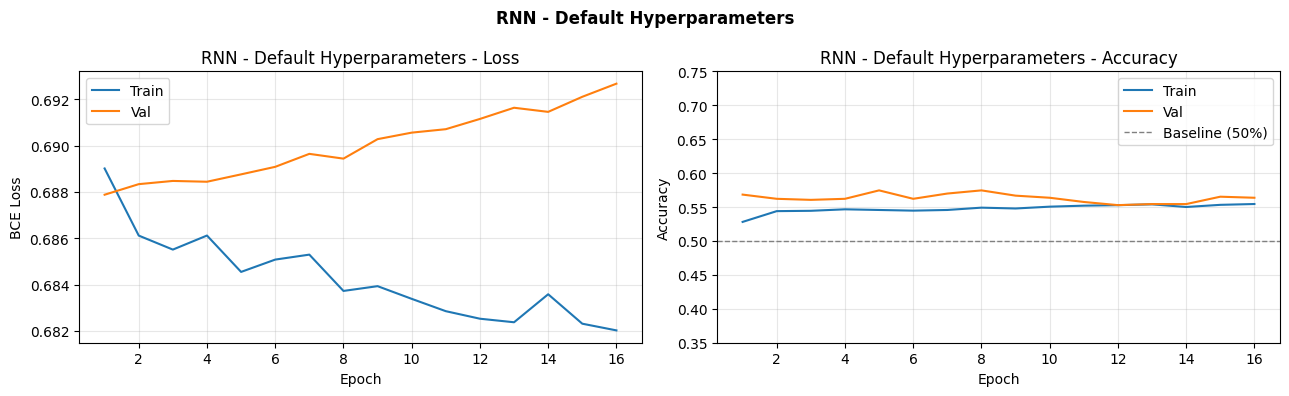

RNN Test Results
  Acc       : 0.5557
  F1        : 0.6877
  Precision : 0.5704
  Recall    : 0.8658

              precision    recall  f1-score   support

        Down       0.47      0.15      0.23       281
          Up       0.57      0.87      0.69       365

    accuracy                           0.56       646
   macro avg       0.52      0.51      0.46       646
weighted avg       0.53      0.56      0.49       646



In [ ]:
plot_history(rnn_hist, 'RNN - Default Hyperparameters', save=SAVE_DIR+'rnn_history.png')

_, rnn_te_p, rnn_te_l = run_epoch(rnn_model, test_loader, None, DEVICE)
rnn_te_m = compute_metrics(rnn_te_p, rnn_te_l)

print("RNN Test Results")
for k, v in rnn_te_m.items():
    print(f"  {k.capitalize():10s}: {v:.4f}")

print("\n" + classification_report(rnn_te_l, rnn_te_p,
      target_names=['Down','Up']))

These are promising first results for our initial RNN, they show accuracy above the guessing 0.5 (but just barely). They do show some form of learning over epochs and reduction in errors.

4.2 b. Train LSTM and plot results

In [ ]:
lstm_model = LSTM(INPUT_SIZE, hidden_size=64, num_layers=2, dropout=0.3).to(DEVICE)
n_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"LSTM trainable params: {n_lstm:,}\n")

t0 = time.time()
lstm_hist = train_model(lstm_model, train_loader, val_loader, lr=1e-3, weight_decay=1e-4, name='LSTM', patience=15)
print(f"\nLSTM wall-clock: {time.time()-t0:.1f}s")

LSTM trainable params: 52,289

[LSTM] Ep   1/60 | TrLoss=0.6882 TrAcc=0.5413 | VaLoss=0.6893 VaAcc=0.5497 VaF1=0.7094
[LSTM] Ep  10/60 | TrLoss=0.6850 TrAcc=0.5383 | VaLoss=0.6875 VaAcc=0.5606 VaF1=0.7133
[LSTM] Ep  20/60 | TrLoss=0.6819 TrAcc=0.5476 | VaLoss=0.6892 VaAcc=0.5606 VaF1=0.6894
[LSTM] Early stop at epoch 28.

LSTM wall-clock: 18.0s


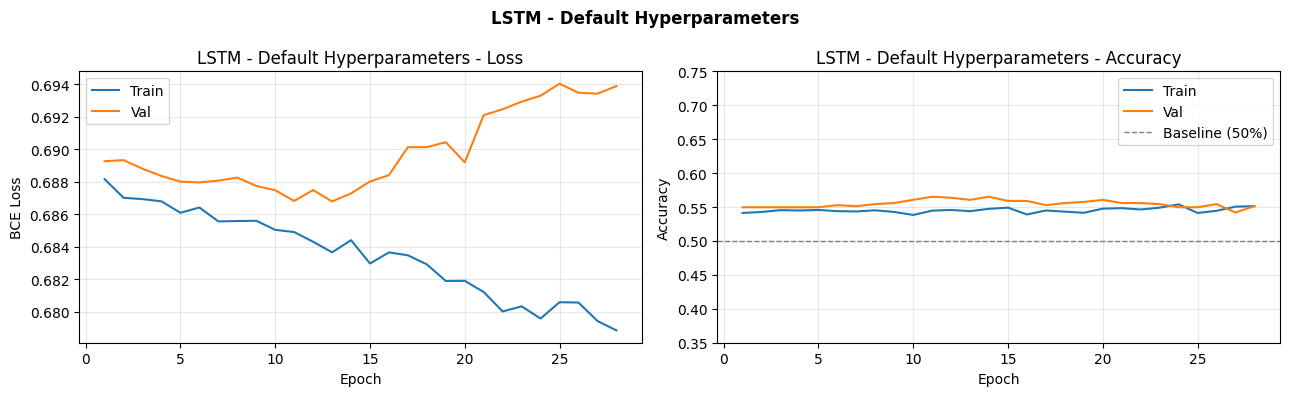

LSTM Test Results
  Acc       : 0.5573
  F1        : 0.6977
  Precision : 0.5680
  Recall    : 0.9041

              precision    recall  f1-score   support

        Down       0.46      0.11      0.17       281
          Up       0.57      0.90      0.70       365

    accuracy                           0.56       646
   macro avg       0.51      0.51      0.44       646
weighted avg       0.52      0.56      0.47       646



In [ ]:
plot_history(lstm_hist, 'LSTM - Default Hyperparameters', save=SAVE_DIR+'lstm_history.png')

_, lstm_te_p, lstm_te_l = run_epoch(lstm_model, test_loader, None, DEVICE)
lstm_te_m = compute_metrics(lstm_te_p, lstm_te_l)

print("LSTM Test Results")

for k, v in lstm_te_m.items():
    print(f"  {k.capitalize():10s}: {v:.4f}")

print("\n" + classification_report(lstm_te_l, lstm_te_p,
      target_names=['Down','Up']))

Again, very promising and is slightly better than guessing. Great baseline for the initial LSTM model.

4.2 c. Train transformer and show plots

In [ ]:
tf_model = Transformer(INPUT_SIZE, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.3).to(DEVICE)
n_tf = sum(p.numel() for p in tf_model.parameters() if p.requires_grad)
print(f"Transformer trainable params: {n_tf:,}\n")

t0 = time.time()
tf_hist = train_model(tf_model, train_loader, val_loader, lr=5e-4, weight_decay=1e-4, name='Transformer', patience=15)
print(f"\nTransformer wall-clock: {time.time()-t0:.1f}s")

Transformer trainable params: 67,585

[Transformer] Ep   1/60 | TrLoss=0.7392 TrAcc=0.5173 | VaLoss=0.6979 VaAcc=0.5543 VaF1=0.7110
[Transformer] Ep  10/60 | TrLoss=0.6887 TrAcc=0.5347 | VaLoss=0.6886 VaAcc=0.5683 VaF1=0.7086
[Transformer] Ep  20/60 | TrLoss=0.6861 TrAcc=0.5410 | VaLoss=0.6879 VaAcc=0.5637 VaF1=0.7124
[Transformer] Ep  30/60 | TrLoss=0.6846 TrAcc=0.5454 | VaLoss=0.6893 VaAcc=0.5559 VaF1=0.7076
[Transformer] Early stop at epoch 39.

Transformer wall-clock: 72.1s


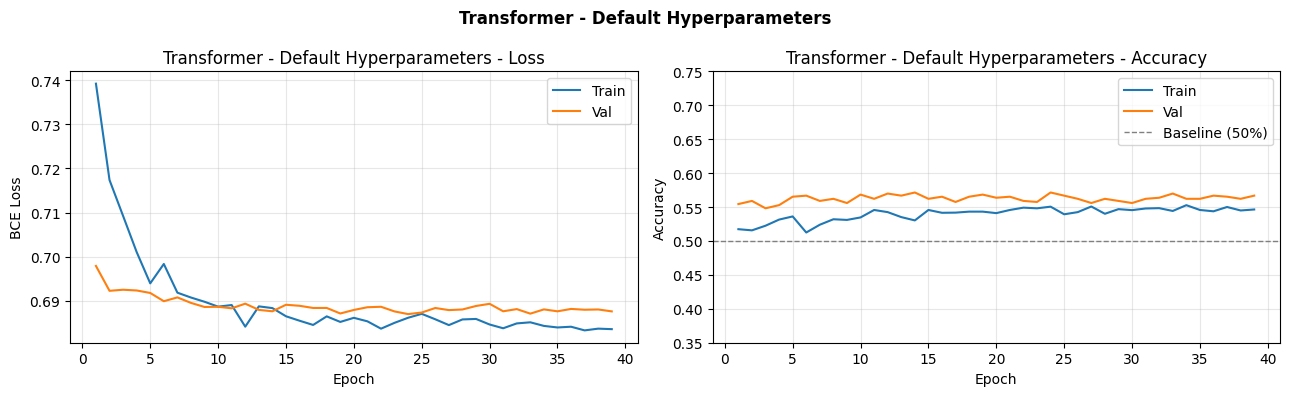

Transformer Test Results:

  Acc       : 0.5588
  F1        : 0.6978
  Precision : 0.5692
  Recall    : 0.9014

              precision    recall  f1-score   support

        Down       0.47      0.11      0.18       281
          Up       0.57      0.90      0.70       365

    accuracy                           0.56       646
   macro avg       0.52      0.51      0.44       646
weighted avg       0.53      0.56      0.47       646



In [ ]:
plot_history(tf_hist, 'Transformer - Default Hyperparameters', save=SAVE_DIR+'transformer_history.png')

_, tf_te_p, tf_te_l = run_epoch(tf_model, test_loader, None, DEVICE)
tf_te_m = compute_metrics(tf_te_p, tf_te_l)

print("Transformer Test Results:\n")
for k, v in tf_te_m.items():
    print(f"  {k.capitalize():10s}: {v:.4f}")

print("\n" + classification_report(tf_te_l, tf_te_p,
      target_names=['Down','Up']))

This noticably reports the worst accuracy among the three, still better than guessing though. It is rather bumpy in the metrics reported. Shows slight overfitting near the end of the epochs it trained on.

# 5. Optuna Hyperparameter Tuning across models:

# COMMENTED OUT FOR FINAL REVISIONS

After the initial model creation and training on uniform input and using the same functions, we can begin to improve and optimize these models via hyperparameter tuning. Using the best modern techniques, I use Bayesian Optimization through Optuna.

In [ ]:
# # Optuna docs: https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html

# # hidden_size search space capped at 128 - larger sizes showed minimal gain
# # in preliminary runs and increased trial time significantly

# OPTUNA_EPOCHS = 30
# OPTUNA_TRIALS = 20

# # Lightweight eval loop for Optuna - no scheduler, no early stopping
# # trades some accuracy for ~3x faster trial iteration
# # returning best val acc across epochs rather than final epoch

# def _quick_train(model, optimizer, n_epochs):
#     best_va = 0.0

#     for _ in range(n_epochs):
#         run_epoch(model, train_loader, optimizer, DEVICE)
#         _, vp, vl = run_epoch(model, val_loader, None, DEVICE)
#         va = accuracy_score(vl, vp)

#         if va > best_va:
#             best_va = va

#     return best_va


# def rnn_objective(trial):
#     hs = trial.suggest_categorical('hidden_size', [32, 64, 128])
#     lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
#     dp = trial.suggest_float('dropout', 0.1, 0.5)
#     wd = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
#     m = RNN(INPUT_SIZE, hs, 1, dp).to(DEVICE)
#     opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)

#     return -_quick_train(m, opt, OPTUNA_EPOCHS)


# def lstm_objective(trial):
#     hs = trial.suggest_categorical('hidden_size', [32, 64, 128])
#     lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
#     dp = trial.suggest_float('dropout', 0.1, 0.5)
#     wd = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
#     m = LSTM(INPUT_SIZE, hs, 2, dp).to(DEVICE)
#     opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)

#     return -_quick_train(m, opt, OPTUNA_EPOCHS)


# def tf_objective(trial):
#     d_model = trial.suggest_categorical('d_model', [32, 64])
#     nhead = trial.suggest_categorical('nhead', [2, 4])

#     if d_model % nhead != 0:
#         raise optuna.exceptions.TrialPruned()

#     lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
#     dp = trial.suggest_float('dropout', 0.1, 0.4)
#     wd = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
#     m = Transformer(INPUT_SIZE, d_model, nhead, 2, 128, dp).to(DEVICE)
#     opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)

#     return -_quick_train(m, opt, OPTUNA_EPOCHS)


# print(f"Starting Optuna search - {OPTUNA_TRIALS} trials x 3 models "
#       f"x {OPTUNA_EPOCHS} epochs each …")

# sampler = TPESampler(seed=SEED)
# rnn_study = optuna.create_study(direction='minimize', sampler=sampler)
# lstm_study = optuna.create_study(direction='minimize', sampler=sampler)
# tf_study = optuna.create_study(direction='minimize', sampler=sampler)

# rnn_study.optimize(rnn_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
# print("RNN done.")
# lstm_study.optimize(lstm_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
# print("LSTM done.")
# tf_study.optimize(tf_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
# print("Transformer done.")

# print("\nBest Hyperparameters:\n\n")
# for sname, study in [('RNN', rnn_study), ('LSTM', lstm_study), ('Transformer', tf_study)]:
#     print(f"  {sname:12s} | Best Val Acc: {-study.best_value:.4f} | {study.best_params}")

Starting Optuna search - 20 trials x 3 models x 30 epochs each …
RNN done.
LSTM done.
Transformer done.

Best Hyperparameters:


  RNN          | Best Val Acc: 0.5901 | {'hidden_size': 32, 'lr': 0.0004489707434583129, 'dropout': 0.2874820875551369, 'weight_decay': 0.00024572827293328065}
  LSTM         | Best Val Acc: 0.5839 | {'hidden_size': 64, 'lr': 0.0010122213485604836, 'dropout': 0.17141019792045287, 'weight_decay': 1.5157130394977194e-05}
  Transformer  | Best Val Acc: 0.5823 | {'d_model': 64, 'nhead': 2, 'lr': 0.0002439242644706783, 'dropout': 0.2281323365878769, 'weight_decay': 0.0004325432427964555}


This has now found the most optimal parameters for these various models. We must be cautious while examining these before we retrain fully with these most optimal hyperparameters (this follows below).

# Hardcode previous Optuna results:

In [ ]:
class _FrozenStudy:
    def __init__(self, params, val_acc):
        self.best_params = params
        self.best_value = -val_acc

rnn_study = _FrozenStudy(
    {'hidden_size': 32, 'lr': 0.0004489707434583129,
     'dropout': 0.2874820875551369, 'weight_decay': 0.00024572827293328065}, 0.5901)

lstm_study = _FrozenStudy(
    {'hidden_size': 64, 'lr': 0.0010122213485604836,
     'dropout': 0.17141019792045287, 'weight_decay': 1.5157130394977194e-05}, 0.5839)

tf_study = _FrozenStudy(
    {'d_model': 64, 'nhead': 2, 'lr': 0.0002439242644706783,
     'dropout': 0.2281323365878769, 'weight_decay': 0.0004325432427964555}, 0.5823)

for _n, _s in [('RNN', rnn_study), ('LSTM', lstm_study), ('Transformer', tf_study)]:
    print(f"{_n:12s} | {_s.best_params}")

# class balance on the windowed training labels
_eff = train_df['Label'].values[WINDOW_SIZE:]
print(f"\nWindowed training labels: UP {(_eff==1).sum()} "
      f"({100*(_eff==1).mean():.2f}%)  DOWN {(_eff==0).sum()} "
      f"({100*(_eff==0).mean():.2f}%)")

RNN          | {'hidden_size': 32, 'lr': 0.0004489707434583129, 'dropout': 0.2874820875551369, 'weight_decay': 0.00024572827293328065}
LSTM         | {'hidden_size': 64, 'lr': 0.0010122213485604836, 'dropout': 0.17141019792045287, 'weight_decay': 1.5157130394977194e-05}
Transformer  | {'d_model': 64, 'nhead': 2, 'lr': 0.0002439242644706783, 'dropout': 0.2281323365878769, 'weight_decay': 0.0004325432427964555}

Windowed training labels: UP 2234 (54.37%)  DOWN 1875 (45.63%)


Retrain with Best Hyperparameters

In [ ]:
# Transformer uses different constructor args than RNN/LSTM,
# so rebuild kwargs entirely rather than updating shared defaults

def retrain(model_cls, best_params, name, num_layers=1):
    if model_cls == Transformer:
        kwargs = dict(
            input_size = INPUT_SIZE,
            d_model = best_params.get('d_model', 64),
            nhead = best_params.get('nhead', 4),
            num_layers = 2,
            dim_feedforward = 128,
            dropout = best_params.get('dropout', 0.3),
        )

    else:
        kwargs = dict(
            input_size = INPUT_SIZE,
            hidden_size = best_params.get('hidden_size', 64),
            num_layers = num_layers,
            dropout = best_params.get('dropout', 0.3),
        )

    m = model_cls(**kwargs).to(DEVICE)
    h = train_model(m, train_loader, val_loader,
                    lr = best_params.get('lr', 1e-3),
                    weight_decay = best_params.get('weight_decay', 1e-4),
                    name = name, patience=15)
    return m, h


rnn_tuned, rnn_hist_t = retrain(RNN, rnn_study.best_params, 'RNN-Tuned',  num_layers=1)
lstm_tuned, lstm_hist_t = retrain(LSTM, lstm_study.best_params, 'LSTM-Tuned', num_layers=2)
tf_tuned, tf_hist_t = retrain(Transformer, tf_study.best_params, 'Transformer-Tuned')

print("\nAll tuned models ready.")

[RNN-Tuned] Ep   1/60 | TrLoss=0.6889 TrAcc=0.5322 | VaLoss=0.6877 VaAcc=0.5606 VaF1=0.7103
[RNN-Tuned] Ep  10/60 | TrLoss=0.6860 TrAcc=0.5435 | VaLoss=0.6863 VaAcc=0.5932 VaF1=0.7213
[RNN-Tuned] Ep  20/60 | TrLoss=0.6843 TrAcc=0.5483 | VaLoss=0.6868 VaAcc=0.5823 VaF1=0.7104
[RNN-Tuned] Early stop at epoch 23.
[LSTM-Tuned] Ep   1/60 | TrLoss=0.6890 TrAcc=0.5332 | VaLoss=0.6903 VaAcc=0.5497 VaF1=0.7094
[LSTM-Tuned] Ep  10/60 | TrLoss=0.6810 TrAcc=0.5386 | VaLoss=0.6891 VaAcc=0.5606 VaF1=0.6934
[LSTM-Tuned] Ep  20/60 | TrLoss=0.6646 TrAcc=0.5862 | VaLoss=0.7059 VaAcc=0.5311 VaF1=0.6244
[LSTM-Tuned] Early stop at epoch 21.
[Transformer-Tuned] Ep   1/60 | TrLoss=0.7198 TrAcc=0.5164 | VaLoss=0.6931 VaAcc=0.5575 VaF1=0.6801
[Transformer-Tuned] Ep  10/60 | TrLoss=0.6917 TrAcc=0.5308 | VaLoss=0.6907 VaAcc=0.5590 VaF1=0.6728
[Transformer-Tuned] Ep  20/60 | TrLoss=0.6877 TrAcc=0.5378 | VaLoss=0.6893 VaAcc=0.5606 VaF1=0.6859
[Transformer-Tuned] Ep  30/60 | TrLoss=0.6849 TrAcc=0.5422 | VaLoss=0.68

This trains these final models and now is prepared to report final results in the following section.

# 6. Comparison and Results (including charts and final metrics)
Evaluate All Tuned Models

In [ ]:
# Report results

MODELS = {
    'RNN': (rnn_tuned,  rnn_hist_t),
    'LSTM':(lstm_tuned, lstm_hist_t),
    'Transformer': (tf_tuned,   tf_hist_t),
}

results = {}
for mname, (model, _) in MODELS.items():
    _, tr_p, tr_l = run_epoch(model, train_loader, None, DEVICE)
    _, va_p, va_l = run_epoch(model, val_loader,   None, DEVICE)
    _, te_p, te_l = run_epoch(model, test_loader,  None, DEVICE)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    results[mname] = dict(
        train_acc = compute_metrics(tr_p, tr_l)['acc'],
        val_acc = compute_metrics(va_p, va_l)['acc'],
        **{f'test_{k}': v for k, v in compute_metrics(te_p, te_l).items()},
        n_params = n_params,
        te_preds = te_p,
        te_labels = te_l,
    )

    print(f"  {mname:12s} | TrainAcc={results[mname]['train_acc']:.4f} "
          f"| ValAcc = {results[mname]['val_acc']:.4f} "
          f"| TestAcc = {results[mname]['test_acc']:.4f} "
          f"| TestF1 = {results[mname]['test_f1']:.4f} "
          f"| Params = {n_params:,}")

  RNN          | TrainAcc=0.5464 | ValAcc = 0.5854 | TestAcc = 0.5619 | TestF1 = 0.7037 | Params = 1,377
  LSTM         | TrainAcc=0.5444 | ValAcc = 0.5606 | TestAcc = 0.5573 | TestF1 = 0.7070 | Params = 52,289
  Transformer  | TrainAcc=0.5447 | ValAcc = 0.5637 | TestAcc = 0.5619 | TestF1 = 0.7073 | Params = 67,585


This shows a comparitive analysis of the models.

Loss and Accuracy Plots

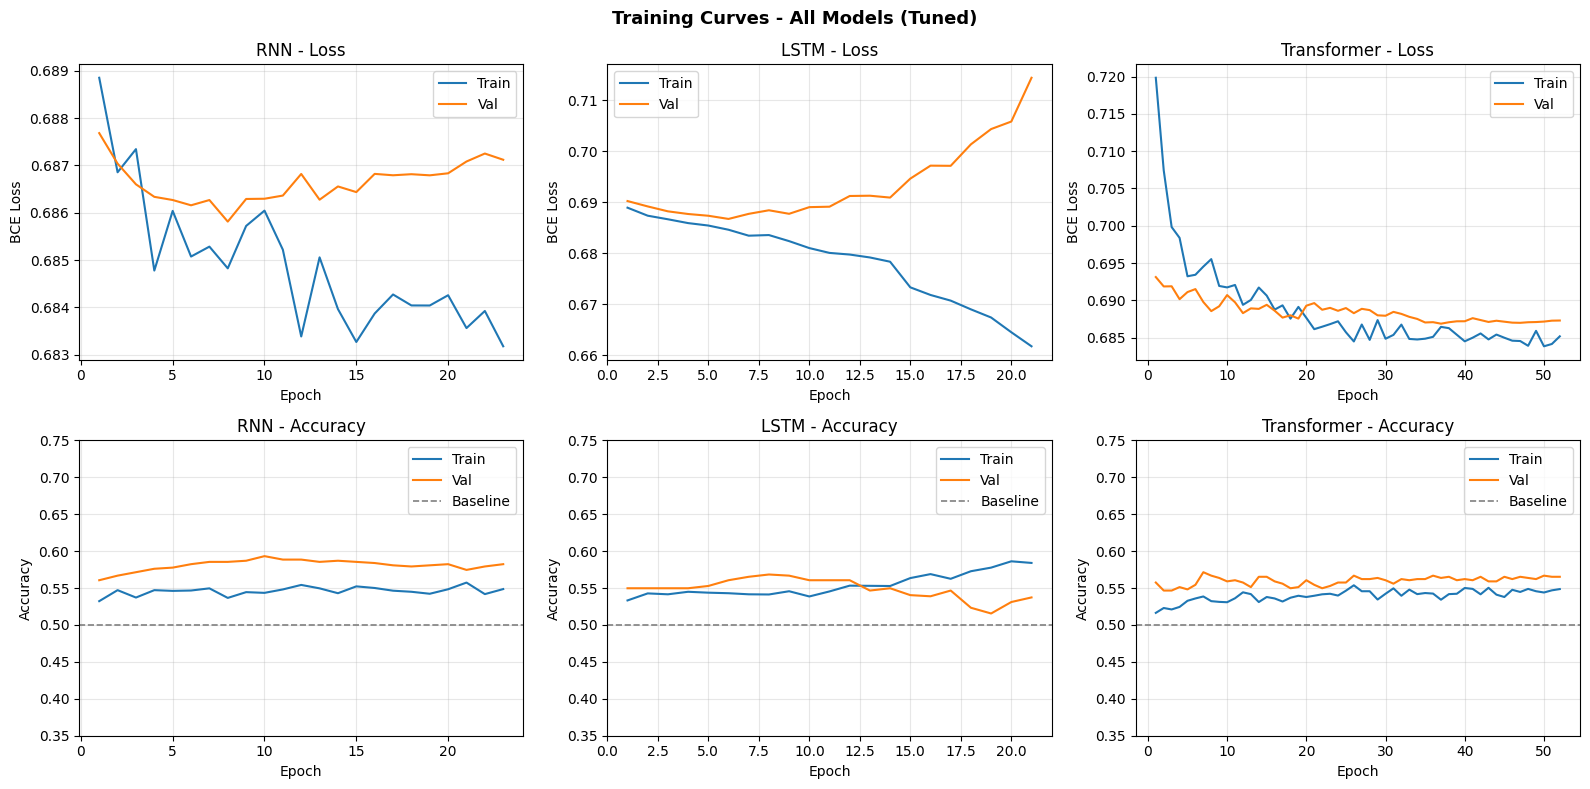

In [ ]:
# Loss and Accuracy Plots

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
c_tr, c_va = '#1f77b4', '#ff7f0e'

for col, (mname, (_, hist)) in enumerate(MODELS.items()):
    ep = range(1, len(hist['train_loss']) + 1)

    axes[0,col].plot(ep, hist['train_loss'], color=c_tr, lw=1.5, label='Train')
    axes[0,col].plot(ep, hist['val_loss'], color=c_va, lw=1.5, label='Val')
    axes[0,col].set(title=f'{mname} - Loss', xlabel='Epoch', ylabel='BCE Loss')
    axes[0,col].legend(); axes[0,col].grid(alpha=0.3)

    axes[1,col].plot(ep, hist['train_acc'], color=c_tr, lw=1.5, label='Train')
    axes[1,col].plot(ep, hist['val_acc'], color=c_va, lw=1.5, label='Val')
    axes[1,col].axhline(0.5, color='grey', ls='--', lw=1.2, label='Baseline')
    axes[1,col].set(title=f'{mname} - Accuracy', xlabel='Epoch',
                    ylabel='Accuracy', ylim=(0.35, 0.75))
    axes[1,col].legend(); axes[1,col].grid(alpha=0.3)

plt.suptitle('Training Curves - All Models (Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR+'all_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

This demonstrates the various metrics across models in a side-by-side view for easy analysis. Most notably, the three models have very similar ending validation accuracy reports. All coming in approximately at the same accuracy and only varying in exact smoothness of accuracy trends and gap between training and validation accuracy. The TF and RNN report similar metrics (the TF being bumpier), while the LSTM eventually clearly overfits.

The loss graphs are far more notable and show how much each model improves on the loss. The TF and RNN have fairly similar graphs while the LSTM shows a sharp decrease in initial training loss, while later then maintaining a close training and validation loss difference. The other two models gradually widen this loss gap, though, although the RNN has a flatlining validation loss and spike in training loss near the end. The LSTM loss graph does report troubling metrics with the validation loss being dramatically higher as time goes on.

Summary Comparison Table

In [ ]:
# Nice looking side-by-side table.

rows = []
for mname, r in results.items():
    rows.append({
        'Model': mname,
        'Train Acc': f"{r['train_acc']:.4f}",
        'Val Acc': f"{r['val_acc']:.4f}",
        'Test Acc': f"{r['test_acc']:.4f}",
        'Test F1': f"{r['test_f1']:.4f}",
        'Test Precision': f"{r['test_precision']:.4f}",
        'Test Recall': f"{r['test_recall']:.4f}",
        'Parameters': f"{r['n_params']:,}",
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print("\n" + "="*75)
print("FINAL MODEL COMPARISON TABLE")
print("-"*75)
print(summary_df.to_string())
print("-"*75)
print("\nBaseline (random): 50.00%")
summary_df


FINAL MODEL COMPARISON TABLE
---------------------------------------------------------------------------
            Train Acc Val Acc Test Acc Test F1 Test Precision Test Recall Parameters
Model                                                                               
RNN            0.5464  0.5854   0.5619  0.7037         0.5695      0.9205      1,377
LSTM           0.5444  0.5606   0.5573  0.7070         0.5646      0.9452     52,289
Transformer    0.5447  0.5637   0.5619  0.7073         0.5681      0.9370     67,585
---------------------------------------------------------------------------

Baseline (random): 50.00%


,Train Acc,Val Acc,Test Acc,Test F1,Test Precision,Test Recall,Parameters
Model,,,,,,,
RNN,0.5464,0.5854,0.5619,0.7037,0.5695,0.9205,"1,377"
LSTM,0.5444,0.5606,0.5573,0.7070,0.5646,0.9452,"52,289"
Transformer,0.5447,0.5637,0.5619,0.7073,0.5681,0.9370,"67,585"


This reports a easy to read comparison of metrics.

Bar Charts

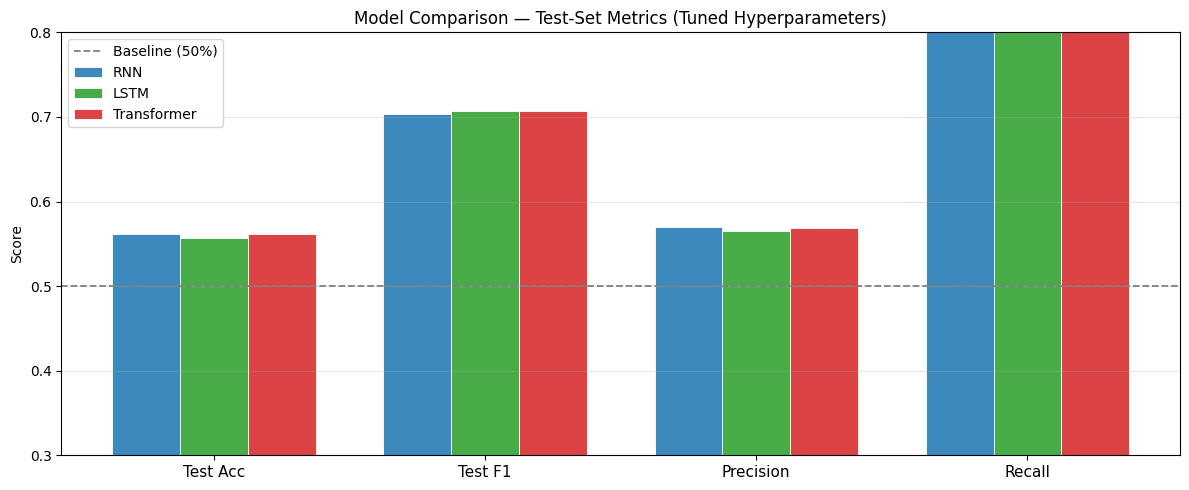

In [ ]:
# Bar charts!!

metric_keys = ['test_acc',  'test_f1', 'test_precision', 'test_recall']
metric_labels = ['Test Acc', 'Test F1', 'Precision', 'Recall']
model_names = list(results.keys())
colours = ['#1f77b4', '#2ca02c', '#d62728']

x = np.arange(len(metric_keys))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for i, (mname, colour) in enumerate(zip(model_names, colours)):
    vals = [results[mname][k] for k in metric_keys]
    ax.bar(x + i*w, vals, width=w, label=mname, color=colour,
           alpha=0.87, edgecolor='white', lw=0.7)

ax.axhline(0.5, color='grey', ls='--', lw=1.3, label='Baseline (50%)')
ax.set_xticks(x + w); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set(ylabel='Score', ylim=(0.30, 0.80),
       title='Model Comparison — Test-Set Metrics (Tuned Hyperparameters)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR+'model_comparison_bars.png', dpi=120, bbox_inches='tight')
plt.show()

These act as a further visualization as a bar chart for out models metrics.

Confusion Matrices

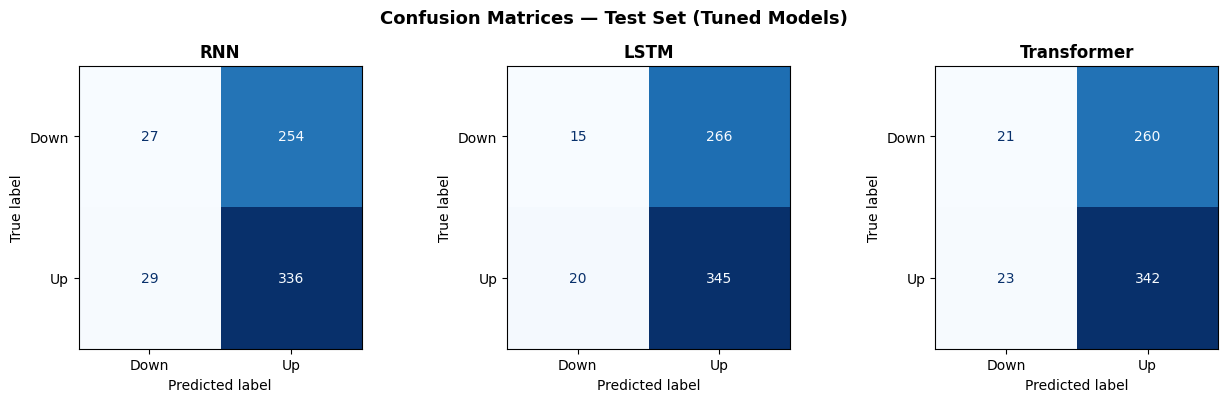

In [ ]:
# Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (mname, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        r['te_labels'], r['te_preds'],
        display_labels=['Down','Up'],
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(mname, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set (Tuned Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR+'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

Again, we have confusion matrices showing a distribution that is very similar across models.

# 7. Threshold Tuning

Val set threshold tuning results:

RNN -- best threshold: 0.530 | Val Macro F1: 0.5481 | Val Acc: 0.5730 | Precision: 0.5896 | Recall: 0.7345
LSTM -- best threshold: 0.530 | Val Macro F1: 0.5338 | Val Acc: 0.5481 | Precision: 0.5782 | Recall: 0.6582
Transformer -- best threshold: 0.530 | Val Macro F1: 0.5410 | Val Acc: 0.5621 | Precision: 0.5841 | Recall: 0.7062
  RNN -- Validation Threshold Sweep

   Threshold    Macro F1    Accuracy   Precision      Recall

        0.30      0.3547      0.5497      0.5497      1.0000
        0.31      0.3547      0.5497      0.5497      1.0000
        0.32      0.3547      0.5497      0.5497      1.0000
        0.33      0.3547      0.5497      0.5497      1.0000
        0.34      0.3547      0.5497      0.5497      1.0000
        0.35      0.3547      0.5497      0.5497      1.0000
        0.36      0.3547      0.5497      0.5497      1.0000
        0.37      0.3547      0.5497      0.5497      1.0000
        0.38      0.3547      0.5497      0.5497

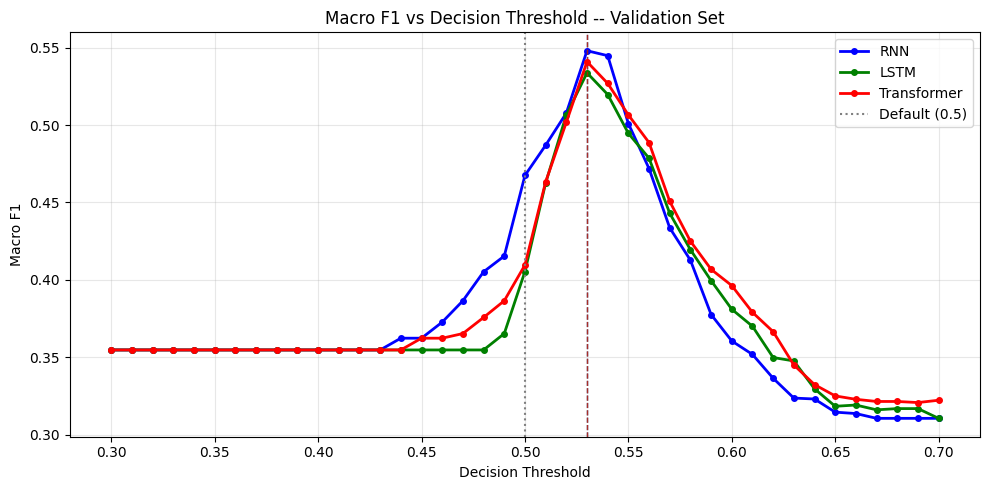

TEST SET: Default (0.5) vs Best Validation Threshold

  Model          Threshold    Macro F1    Accuracy   Recall (Down)

  RNN           0.50 (base)      0.4320      0.5619          0.0961
                      0.53             0.4918      0.5170          0.3381
  -----------------------------------------------------------------
  LSTM          0.50 (base)      0.4010      0.5573          0.0534
                      0.53             0.4798      0.4923          0.3879
  -----------------------------------------------------------------
  Transformer   0.50 (base)      0.4183      0.5619          0.0747
                      0.53             0.4920      0.5046          0.3986
  -----------------------------------------------------------------


In [ ]:
# Inference-Side threshold Tuning and Probability Distributions
# Goal is to find the optimal threshold that maximizes Macro F1 on validation set and apply on test set to measure real-world gain.

import matplotlib.ticker as mticker

THRESHOLDS = np.arange(0.3, 0.71, 0.01)

# Collect raw sigmoid probs and labels for a loader. Returns as an array formatted like (N, ) for both probs and labels.

def get_probs(model, loader, device=DEVICE):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(DEVICE)
            logits = model(X_b).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)

# With given probs and labels, evaluate each threshold.

def threshold_sweep(probs, labels, thresholds):
    rows = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 3),
            'macro_f1':  round(f1_score(labels, preds, average='macro',  zero_division=0), 4),
            'acc':       round(accuracy_score(labels, preds), 4),
            'precision': round(precision_score(labels, preds, zero_division=0), 4),
            'recall':    round(recall_score(labels, preds, zero_division=0), 4),
        })
    return rows

# Get validation probs and labels for each model, find best threshold, and apply to test set.

val_probs = {}
val_labels_ref = None


for mname, (model, _) in MODELS.items():
    probs, labels = get_probs(model, val_loader, DEVICE)
    val_probs[mname] = probs

    if val_labels_ref is None:
        val_labels_ref = labels

print("Val set threshold tuning results:\n")

# Find best threshold for each model based on validation Macro F1

sweep_results = {}
best_thresholds = {}

for mname, probs in val_probs.items():
    rows = threshold_sweep(probs, val_labels_ref, THRESHOLDS)
    sweep_results[mname] = rows
    best_row = max(rows, key=lambda x: x['macro_f1'])
    best_thresholds[mname] = best_row['threshold']
    print(f"{mname} -- best threshold: {best_row['threshold']:.3f} | Val Macro F1: {best_row['macro_f1']:.4f} | Val Acc: {best_row['acc']:.4f} | Precision: {best_row['precision']:.4f} | Recall: {best_row['recall']:.4f}")

# Print full sweep results for one model as example
for mname, rows in sweep_results.items():
    print(f"  {mname} -- Validation Threshold Sweep\n")
    print(f"  {'Threshold':>10}  {'Macro F1':>10}  {'Accuracy':>10}  {'Precision':>10}  {'Recall':>10}\n")
    for r in rows:
        marker = '  <-- best' if r['threshold'] == best_thresholds[mname] else ''
        print(f"  {r['threshold']:>10.2f}  {r['macro_f1']:>10.4f}  {r['acc']:>10.4f}  {r['precision']:>10.4f}  {r['recall']:>10.4f}{marker}")

# Plot Macro F1 vs threshold for all three models
fig, ax = plt.subplots(figsize=(10, 5))
colours = {'RNN': 'blue', 'LSTM': 'green', 'Transformer': 'red'}

for mname, rows in sweep_results.items():
    xs = [r['threshold'] for r in rows]
    ys = [r['macro_f1'] for r in rows]
    ax.plot(xs, ys, label=mname, color=colours[mname], lw=2.0, marker='o', ms=4)
    ax.axvline(best_thresholds[mname], color=colours[mname], ls='--', lw=1.0, alpha=0.6)

ax.axvline(0.5, color='grey', ls=':', lw=1.5, label='Default (0.5)')
ax.set(xlabel='Decision Threshold', ylabel='Macro F1',
       title='Macro F1 vs Decision Threshold -- Validation Set',
       xlim=(0.28, 0.72))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR+'threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# Apply the best validation threshold to the test set and compare against 0.5 baseline
test_probs = {}
for mname, (model, _) in MODELS.items():
    probs, te_labels = get_probs(model, test_loader)
    test_probs[mname] = (probs, te_labels)

print("TEST SET: Default (0.5) vs Best Validation Threshold\n")
print(f"  {'Model':12s}  {'Threshold':>10}  {'Macro F1':>10}  {'Accuracy':>10}  {'Recall (Down)':>14}\n")

for mname in MODELS:
    probs, te_l = test_probs[mname]

    # default
    preds_05 = (probs >= 0.5).astype(int)
    f1_05 = f1_score(te_l, preds_05, average='macro', zero_division=0)
    acc_05 = accuracy_score(te_l, preds_05)
    rec_down_05 = recall_score(te_l, preds_05, pos_label=0, zero_division=0)

    # tuned
    best_t = best_thresholds[mname]
    preds_t = (probs >= best_t).astype(int)
    f1_t = f1_score(te_l, preds_t, average='macro', zero_division=0)
    acc_t = accuracy_score(te_l, preds_t)
    rec_down_t = recall_score(te_l, preds_t, pos_label=0, zero_division=0)

    print(f"  {mname:12s}  {'0.50 (base)':>10}  {f1_05:>10.4f}  {acc_05:>10.4f}  {rec_down_05:>14.4f}")
    print(f"  {' ':12s}  {best_t:>10.2f}         {f1_t:>10.4f}  {acc_t:>10.4f}  {rec_down_t:>14.4f}")
    print(f"  {'-'*65}")

# 8. Cost-Sensitive Training Sweep

# Following Review, the commented cell was replaced with a cell analy

In [ ]:
CS_CKPT = SAVE_DIR + "cs_checkpoints/"
os.makedirs(CS_CKPT, exist_ok=True)

CS_CONFIGS = [
    ("RNN",         RNN,         rnn_study.best_params,  1),
    ("LSTM",        LSTM,        lstm_study.best_params, 2),
    ("Transformer", Transformer, tf_study.best_params,   None),
]

def _build(ModelClass, params, num_layers):
    if ModelClass == Transformer:
        return Transformer(input_size=INPUT_SIZE,
                           d_model=params.get('d_model', 64),
                           nhead=params.get('nhead', 4),
                           num_layers=2, dim_feedforward=128,
                           dropout=params.get('dropout', 0.3)).to(DEVICE)
    return ModelClass(input_size=INPUT_SIZE,
                      hidden_size=params.get('hidden_size', 64),
                      num_layers=num_layers,
                      dropout=params.get('dropout', 0.3)).to(DEVICE)

prob_store = {}
for mname, (model, _) in MODELS.items():                 # cache baselines too
    vp, vy = get_probs(model, val_loader,  DEVICE)
    tp, ty = get_probs(model, test_loader, DEVICE)
    prob_store[f"baseline::{mname}"] = dict(val_probs=vp, val_y=vy,
                                            test_probs=tp, test_y=ty)

cs_rows = []
for model_name, ModelClass, params, num_layers in CS_CONFIGS:
    print(f"\n===== {model_name} =====")
    for mult, pw in zip(PW_MULTIPLIERS, PW_SWEEP_VALUES):
        print(f"  pos_weight={pw:.4f} (x{mult}) ...", flush=True)
        model = _build(ModelClass, params, num_layers)
        train_model(model, train_loader, val_loader,
                    lr=params.get('lr', 1e-3),
                    weight_decay=params.get('weight_decay', 1e-4),
                    name=f"{model_name}_pw{pw:.4f}", pos_weight=pw)
        torch.save(model.state_dict(), f"{CS_CKPT}{model_name}_pw{pw:.4f}.pt")

        vp, vy = get_probs(model, val_loader,  DEVICE)
        tp, ty = get_probs(model, test_loader, DEVICE)
        prob_store[f"cs::{model_name}::pw{pw:.4f}"] = dict(
            val_probs=vp, val_y=vy, test_probs=tp, test_y=ty)

        tau_cs = tune_threshold(vp, vy)
        m_cs   = full_metrics(ty, tp, 0.5)       # cost-sensitive alone
        m_cmb  = full_metrics(ty, tp, tau_cs)    # combined, done correctly
        m_old  = full_metrics(ty, tp, best_thresholds[model_name])  # old, wrong way

        cs_rows.append({"Model": model_name, "PW_Mult": mult, "pos_weight": pw,
                        "tau_cs": tau_cs,
                        "tau_baseline_old": best_thresholds[model_name],
                        **{f"CS_{k}": v for k, v in m_cs.items()},
                        **{f"CMB_{k}": v for k, v in m_cmb.items()},
                        "OLD_dn_rec": m_old["dn_rec"],
                        "OLD_macro_f1": m_old["macro_f1"]})
        print(f"    tau*_CS={tau_cs:.2f} (baseline tau was "
              f"{best_thresholds[model_name]:.2f}) | CS acc={m_cs['acc']:.3f} "
              f"DN={m_cs['dn_rec']:.3f} | CMB acc={m_cmb['acc']:.3f} "
              f"DN={m_cmb['dn_rec']:.3f}")
        del model; torch.cuda.empty_cache()

cs_fixed = pd.DataFrame(cs_rows)
cs_fixed.to_csv(SAVE_DIR + "cs_sweep_fixed.csv", index=False)
np.savez_compressed(SAVE_DIR + "prob_store.npz",
    **{f"{k}|{kk}": vv for k, d in prob_store.items() for kk, vv in d.items()})
print("\nSaved cs_sweep_fixed.csv + prob_store.npz + checkpoints to Drive.")


===== RNN =====
  pos_weight=0.2143 (x0.25) ...
[RNN_pw0.2143] Ep   1/60 | TrLoss=0.3302 TrAcc=0.4565 | VaLoss=0.2938 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.2143] Ep  10/60 | TrLoss=0.2891 TrAcc=0.4568 | VaLoss=0.2901 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.2143] Ep  20/60 | TrLoss=0.2889 TrAcc=0.4565 | VaLoss=0.2901 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.2143] Ep  30/60 | TrLoss=0.2879 TrAcc=0.4565 | VaLoss=0.2904 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.2143] Early stop at epoch 33.
    tau*_CS=0.31 (baseline tau was 0.53) | CS acc=0.435 DN=1.000 | CMB acc=0.430 DN=0.989
  pos_weight=0.4286 (x0.5) ...
[RNN_pw0.4286] Ep   1/60 | TrLoss=0.4504 TrAcc=0.4561 | VaLoss=0.4444 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.4286] Ep  10/60 | TrLoss=0.4387 TrAcc=0.4568 | VaLoss=0.4411 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.4286] Ep  20/60 | TrLoss=0.4378 TrAcc=0.4573 | VaLoss=0.4415 VaAcc=0.4519 VaF1=0.0056
[RNN_pw0.4286] Early stop at epoch 23.
    tau*_CS=0.32 (baseline tau was 0.53) | CS acc=0.435 DN=1.000 | CMB acc=0.536 DN=0.3

In [ ]:
master = []
for mname in ["RNN", "LSTM", "Transformer"]:
    b = prob_store[f"baseline::{mname}"]
    master.append({"Model": mname, "Strategy": "Baseline",
                   **full_metrics(b["test_y"], b["test_probs"], 0.5)})
    master.append({"Model": mname, "Strategy": "Threshold",
                   **full_metrics(b["test_y"], b["test_probs"],
                                  best_thresholds[mname])})
    r = cs_fixed[(cs_fixed.Model == mname) & (cs_fixed.PW_Mult == 1.00)].iloc[0]
    master.append({"Model": mname, "Strategy": "Cost-sens.",
                   **{k[3:]: r[k] for k in r.index if k.startswith("CS_")}})
    master.append({"Model": mname, "Strategy": "Combined",
                   **{k[4:]: r[k] for k in r.index if k.startswith("CMB_")}})

master_df = pd.DataFrame(master)
master_df.to_csv(SAVE_DIR + "master_results.csv", index=False)

cols = ["Model", "Strategy", "thr", "acc", "bal_acc", "macro_f1", "mcc",
        "up_prec", "up_rec", "dn_prec", "dn_rec", "roc_auc"]
print(master_df[cols].round(4).to_string(index=False))

print("\n--- DISCRIMINATION CHECK (does cost-sensitive training LEARN anything?) ---")
for mname in ["RNN", "LSTM", "Transformer"]:
    a = master_df[(master_df.Model == mname) & (master_df.Strategy == "Baseline")].iloc[0]
    c = master_df[(master_df.Model == mname) & (master_df.Strategy == "Cost-sens.")].iloc[0]
    print(f"  {mname:12s} ROC-AUC baseline={a.roc_auc:.4f}  "
          f"cost-sens={c.roc_auc:.4f}  delta={c.roc_auc-a.roc_auc:+.4f}")

print("\n--- OLD (wrong) vs NEW (independent) threshold for Combined ---")
for _, r in cs_fixed[cs_fixed.PW_Mult == 1.00].iterrows():
    print(f"  {r.Model:12s} tau: {r.tau_baseline_old:.2f} -> {r.tau_cs:.2f} | "
          f"DN recall: {r.OLD_dn_rec:.3f} -> {r.CMB_dn_rec:.3f} | "
          f"macro F1: {r.OLD_macro_f1:.3f} -> {r.CMB_macro_f1:.3f}")

# LaTeX for Table I
print(r"\begin{table*}[t]\caption{Test-set performance by bias-correction strategy. "
      r"UP is the positive class, so specificity is identical to DN recall. "
      r"ROC-AUC is threshold-invariant.}\begin{center}\small")
print(r"\begin{tabular}{|l|c|c|c|c|c|c|c|c|}\hline")
print(r"\textbf{Strategy} & $\tau$ & \textbf{Acc.(\%)} & \textbf{UP Prec} & "
      r"\textbf{UP Rec} & \textbf{DN Prec} & \textbf{DN Rec (Spec.)} & "
      r"\textbf{Macro F1} & \textbf{ROC-AUC}\\\hline")
for mname in ["RNN", "LSTM", "Transformer"]:
    print(r"\multicolumn{9}{|l|}{\textit{" + mname + r"}}\\\hline")
    for _, r in master_df[master_df.Model == mname].iterrows():
        print(f"{r.Strategy} & {r.thr:.2f} & {100*r.acc:.1f} & {r.up_prec:.3f} & "
              f"{r.up_rec:.3f} & {r.dn_prec:.3f} & {r.dn_rec:.3f} & "
              f"{r.macro_f1:.3f} & {r.roc_auc:.3f}" + r"\\")
    print(r"\hline")
print(r"\end{tabular}\label{tab:comparison}\end{center}\end{table*}")

      Model   Strategy  thr    acc  bal_acc  macro_f1     mcc  up_prec  up_rec  dn_prec  dn_rec  roc_auc
        RNN   Baseline 0.50 0.5619   0.5083    0.4320  0.0293   0.5695  0.9205   0.4821  0.0961   0.5021
        RNN  Threshold 0.53 0.5170   0.4964    0.4918 -0.0074   0.5624  0.6548   0.4299  0.3381   0.5021
        RNN Cost-sens. 0.50 0.4907   0.4916    0.4890 -0.0167   0.5566  0.4849   0.4268  0.4982   0.4933
        RNN   Combined 0.49 0.4876   0.4716    0.4696 -0.0579   0.5425  0.5945   0.3984  0.3488   0.4933
       LSTM   Baseline 0.50 0.5573   0.4993    0.4010 -0.0031   0.5646  0.9452   0.4286  0.0534   0.4894
       LSTM  Threshold 0.53 0.4923   0.4803    0.4798 -0.0398   0.5486  0.5726   0.4113  0.3879   0.4894
       LSTM Cost-sens. 0.50 0.4969   0.4872    0.4872 -0.0256   0.5541  0.5616   0.4203  0.4128   0.4867
       LSTM   Combined 0.50 0.4969   0.4872    0.4872 -0.0256   0.5541  0.5616   0.4203  0.4128   0.4867
Transformer   Baseline 0.50 0.5619   0.5059    0.4183  

In [ ]:
# import os

# os.makedirs("cs_checkpoints", exist_ok=True)

# CS_CONFIGS = [
#     ("RNN",         RNN,         rnn_study.best_params,  1),
#     ("LSTM",        LSTM,        lstm_study.best_params, 2),
#     ("Transformer", Transformer, tf_study.best_params,   None),
# ]

# cs_results = []

# for model_name, ModelClass, params, num_layers in CS_CONFIGS:
#     print(f"MODEL: {model_name}")

#     for i, (mult, pw) in enumerate(zip(PW_MULTIPLIERS, PW_SWEEP_VALUES)):
#         print(f"\n  [{i+1}/{len(PW_SWEEP_VALUES)}] pos_weight={pw:.4f}  (x{mult} natural)  ...", flush=True)

#         if ModelClass == Transformer:
#             model = Transformer(
#                 input_size      = INPUT_SIZE,
#                 d_model         = params.get('d_model', 64),
#                 nhead           = params.get('nhead', 4),
#                 num_layers      = 2,
#                 dim_feedforward = 128,
#                 dropout         = params.get('dropout', 0.3),
#             ).to(DEVICE)
#         else:
#             model = ModelClass(
#                 input_size  = INPUT_SIZE,
#                 hidden_size = params.get('hidden_size', 64),
#                 num_layers  = num_layers,
#                 dropout     = params.get('dropout', 0.3),
#             ).to(DEVICE)

#         train_model(
#             model,
#             train_loader,
#             val_loader,
#             lr           = params.get('lr', 1e-3),
#             weight_decay = params.get('weight_decay', 1e-4),
#             name         = f"{model_name}_pw{pw:.4f}",
#             pos_weight   = pw,
#         )

#         torch.save(model.state_dict(), f"cs_checkpoints/{model_name}_pw{pw:.4f}.pt")

#         # Evaluate on test set at threshold 0.5
#         model.eval()
#         all_probs, all_labels = [], []
#         with torch.no_grad():
#             for X_b, y_b in test_loader:
#                 logits = model(X_b.to(DEVICE)).squeeze(1)
#                 probs  = torch.sigmoid(logits).cpu().numpy()
#                 all_probs.extend(probs)
#                 all_labels.extend(y_b.numpy())

#         probs_arr  = np.array(all_probs)
#         labels_arr = np.array(all_labels)
#         preds_05   = (probs_arr >= 0.5).astype(int)

#         # Also evaluate combined: CS training + best threshold from prior sweep
#         best_t   = best_thresholds[model_name]
#         preds_bt = (probs_arr >= best_t).astype(int)

#         row = {
#             "Model":               model_name,
#             "PW_Mult":             mult,
#             "pos_weight":          pw,
#             "Accuracy":            round(accuracy_score(labels_arr, preds_05),                           4),
#             "Macro_F1":            round(f1_score(labels_arr,       preds_05, average='macro', zero_division=0), 4),
#             "UP_Recall":           round(recall_score(labels_arr,   preds_05, pos_label=1,     zero_division=0), 4),
#             "DOWN_Recall":         round(recall_score(labels_arr,   preds_05, pos_label=0,     zero_division=0), 4),
#             "UP_Prec":             round(precision_score(labels_arr, preds_05, pos_label=1,    zero_division=0), 4),
#             "DOWN_Prec":           round(precision_score(labels_arr, preds_05, pos_label=0,    zero_division=0), 4),
#             "Combined_Macro_F1":   round(f1_score(labels_arr,       preds_bt, average='macro', zero_division=0), 4),
#             "Combined_UP_Recall":  round(recall_score(labels_arr,   preds_bt, pos_label=1,     zero_division=0), 4),
#             "Combined_DOWN_Recall":round(recall_score(labels_arr,   preds_bt, pos_label=0,     zero_division=0), 4),
#         }

#         cs_results.append(row)
#         print(f"  Acc={row['Accuracy']:.3f}  MacroF1={row['Macro_F1']:.3f}  "
#               f"UP_Rec={row['UP_Recall']:.3f}  DN_Rec={row['DOWN_Recall']:.3f}  "
#               f"| Combined MacroF1={row['Combined_Macro_F1']:.3f}  DN_Rec={row['Combined_DOWN_Recall']:.3f}")

#         torch.cuda.empty_cache()

# cs_df = pd.DataFrame(cs_results)
# cs_df.to_csv(SAVE_DIR+"cs_sweep_results.csv", index=False)

# print("\n\n=== Cost-Sensitive Training - Full Sweep Results ===")
# print(cs_df.to_string(index=False))

MODEL: RNN

  [1/6] pos_weight=0.2143  (x0.25 natural)  ...
[RNN_pw0.2143] Ep   1/60 | TrLoss=0.3431 TrAcc=0.4683 | VaLoss=0.2916 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.2143] Ep  10/60 | TrLoss=0.2905 TrAcc=0.4565 | VaLoss=0.2905 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.2143] Ep  20/60 | TrLoss=0.2892 TrAcc=0.4565 | VaLoss=0.2903 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.2143] Ep  30/60 | TrLoss=0.2885 TrAcc=0.4565 | VaLoss=0.2904 VaAcc=0.4503 VaF1=0.0000
[RNN_pw0.2143] Early stop at epoch 37.
  Acc=0.435  MacroF1=0.303  UP_Rec=0.000  DN_Rec=1.000  | Combined MacroF1=0.303  DN_Rec=1.000

  [2/6] pos_weight=0.4286  (x0.5 natural)  ...
[RNN_pw0.4286] Ep   1/60 | TrLoss=0.4513 TrAcc=0.4663 | VaLoss=0.4440 VaAcc=0.4534 VaF1=0.0383
[RNN_pw0.4286] Ep  10/60 | TrLoss=0.4387 TrAcc=0.4561 | VaLoss=0.4408 VaAcc=0.4519 VaF1=0.0222
[RNN_pw0.4286] Ep  20/60 | TrLoss=0.4374 TrAcc=0.4575 | VaLoss=0.4412 VaAcc=0.4550 VaF1=0.0277
[RNN_pw0.4286] Early stop at epoch 28.
  Acc=0.432  MacroF1=0.302  UP_Rec=0.000  DN_Rec=0.993

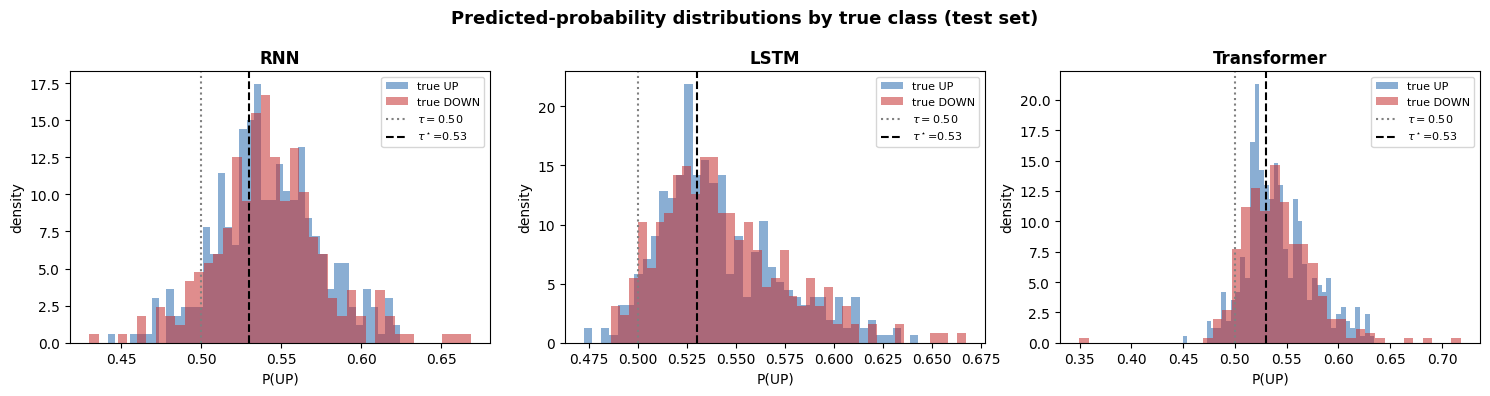

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mname in zip(axes, ["RNN", "LSTM", "Transformer"]):
    b = prob_store[f"baseline::{mname}"]
    ax.hist(b["test_probs"][b["test_y"] == 1], bins=40, alpha=0.55,
            label="true UP", color="#2b6cb0", density=True)
    ax.hist(b["test_probs"][b["test_y"] == 0], bins=40, alpha=0.55,
            label="true DOWN", color="#c53030", density=True)
    ax.axvline(0.5, color="grey", ls=":", lw=1.5, label=r"$\tau=0.50$")
    ax.axvline(best_thresholds[mname], color="black", ls="--", lw=1.5,
               label=rf"$\tau^\star$={best_thresholds[mname]:.2f}")
    ax.set_title(f"{mname}", fontweight="bold")
    ax.set_xlabel("P(UP)"); ax.set_ylabel("density"); ax.legend(fontsize=8)
plt.suptitle("Predicted-probability distributions by true class (test set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "probability_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# 9. Bias Correction Strategy Comparison (Table and Figure)

STRATEGY COMPARISON — Baseline | Threshold Tuning | Cost-Sensitive | Combined

Model         Condition                       Macro F1   UP Recall   DOWN Recall    Accuracy
-------------------------------------------------------------------------------------
RNN           Baseline (t=0.50)                 0.4320      0.9205        0.0961      0.5619
              Threshold Tuning (t=0.53)         0.4918      0.6548        0.3381      0.5170
              Cost-Sensitive (pw=0.8572)        0.4890      0.4849        0.4982      0.4907
              Combined (CS + TT)                0.4696      0.5945        0.3488           —
-------------------------------------------------------------------------------------
LSTM          Baseline (t=0.50)                 0.4010      0.9452        0.0534      0.5573
              Threshold Tuning (t=0.53)         0.4798      0.5726        0.3879      0.4923
              Cost-Sensitive (pw=0.8572)        0.4872      0.5616        0.4128      0.4969
     

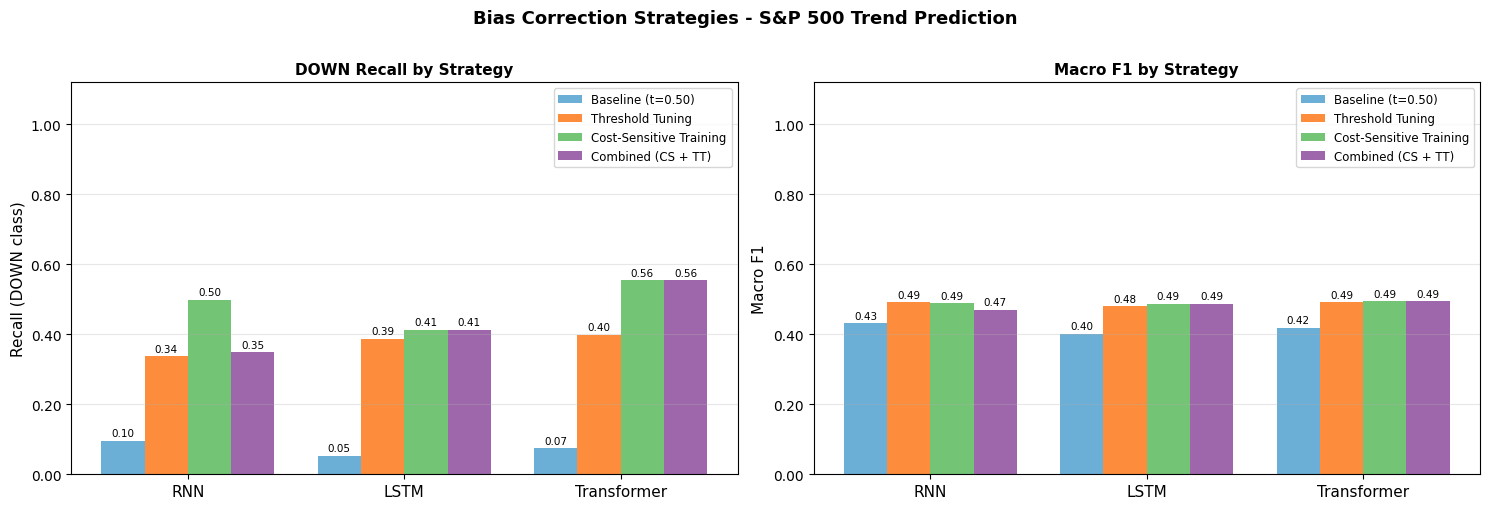

Saved -> paper_comparison_figure.png  |  paper_comparison_table.csv


In [ ]:
import matplotlib.ticker as mticker

cs_df = cs_fixed.rename(columns={
    "CS_acc":"Accuracy", "CS_macro_f1":"Macro_F1",
    "CS_up_rec":"UP_Recall", "CS_dn_rec":"DOWN_Recall",
    "CS_up_prec":"UP_Prec", "CS_dn_prec":"DOWN_Prec",
    "CMB_macro_f1":"Combined_Macro_F1",
    "CMB_up_rec":"Combined_UP_Recall",
    "CMB_dn_rec":"Combined_DOWN_Recall"})

cs_best = cs_df[cs_df["PW_Mult"] == 1.00].set_index("Model")

comp_rows = []
for mname in ["RNN", "LSTM", "Transformer"]:

    # Baseline (t=0.5, original tuned model) — recompute from test_probs
    probs_te, te_l = test_probs[mname]
    preds_05  = (probs_te >= 0.5).astype(int)

    # Threshold tuning — recompute from test_probs + best_thresholds
    best_t   = best_thresholds[mname]
    preds_tt = (probs_te >= best_t).astype(int)

    comp_rows.append({
        "Model":          mname,
        # Baseline
        "BL_Acc":         round(accuracy_score(te_l, preds_05),                               4),
        "BL_Macro_F1":    round(f1_score(te_l,       preds_05, average='macro', zero_division=0), 4),
        "BL_UP_Rec":      round(recall_score(te_l,   preds_05, pos_label=1,     zero_division=0), 4),
        "BL_DN_Rec":      round(recall_score(te_l,   preds_05, pos_label=0,     zero_division=0), 4),
        # Threshold tuning
        "TT_Thresh":      best_t,
        "TT_Acc":         round(accuracy_score(te_l, preds_tt),                               4),
        "TT_Macro_F1":    round(f1_score(te_l,       preds_tt, average='macro', zero_division=0), 4),
        "TT_UP_Rec":      round(recall_score(te_l,   preds_tt, pos_label=1,     zero_division=0), 4),
        "TT_DN_Rec":      round(recall_score(te_l,   preds_tt, pos_label=0,     zero_division=0), 4),
        # Cost-sensitive training (best pos_weight per model)
        "CS_PW":          cs_best.loc[mname, "pos_weight"],
        "CS_PW_Mult":     cs_best.loc[mname, "PW_Mult"],
        "CS_Acc":         cs_best.loc[mname, "Accuracy"],
        "CS_Macro_F1":    cs_best.loc[mname, "Macro_F1"],
        "CS_UP_Rec":      cs_best.loc[mname, "UP_Recall"],
        "CS_DN_Rec":      cs_best.loc[mname, "DOWN_Recall"],
        # Combined: CS training + threshold tuning
        "COMB_Macro_F1":  cs_best.loc[mname, "Combined_Macro_F1"],
        "COMB_UP_Rec":    cs_best.loc[mname, "Combined_UP_Recall"],
        "COMB_DN_Rec":    cs_best.loc[mname, "Combined_DOWN_Recall"],
    })

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(SAVE_DIR+"paper_comparison_table.csv", index=False)

print("=" * 105)
print("STRATEGY COMPARISON — Baseline | Threshold Tuning | Cost-Sensitive | Combined")
print("=" * 105)
print(f"\n{'Model':12s}  {'Condition':28s}  {'Macro F1':>10}  {'UP Recall':>10}  {'DOWN Recall':>12}  {'Accuracy':>10}")
print("-" * 85)
for _, row in comp_df.iterrows():
    m = row["Model"]
    tt_label = f"Threshold Tuning (t={row['TT_Thresh']:.2f})"
    cs_label = f"Cost-Sensitive (pw={row['CS_PW']:.4f})"

    print(f"{m:12s}  {'Baseline (t=0.50)':28s}  {row['BL_Macro_F1']:>10.4f}  {row['BL_UP_Rec']:>10.4f}  {row['BL_DN_Rec']:>12.4f}  {row['BL_Acc']:>10.4f}")
    print(f"{'':12s}  {tt_label:28s}  {row['TT_Macro_F1']:>10.4f}  {row['TT_UP_Rec']:>10.4f}  {row['TT_DN_Rec']:>12.4f}  {row['TT_Acc']:>10.4f}")
    print(f"{'':12s}  {cs_label:28s}  {row['CS_Macro_F1']:>10.4f}  {row['CS_UP_Rec']:>10.4f}  {row['CS_DN_Rec']:>12.4f}  {row['CS_Acc']:>10.4f}")
    print(f"{'':12s}  {'Combined (CS + TT)':28s}  {row['COMB_Macro_F1']:>10.4f}  {row['COMB_UP_Rec']:>10.4f}  {row['COMB_DN_Rec']:>12.4f}  {'—':>10}")
    print("-" * 85)

# Bar chart: 4 conditions x 3 models, DOWN Recall and Macro F1 side by side
x   = np.arange(3)
bw  = 0.20
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
model_labels = ["RNN", "LSTM", "Transformer"]
cond_colours = ["#6baed6", "#fd8d3c", "#74c476", "#9e67ab"]

for ax, bl_col, tt_col, cs_col, cb_col, ylabel, title in [
    (axes[0],
     "BL_DN_Rec", "TT_DN_Rec", "CS_DN_Rec", "COMB_DN_Rec",
     "Recall (DOWN class)", "DOWN Recall by Strategy"),
    (axes[1],
     "BL_Macro_F1", "TT_Macro_F1", "CS_Macro_F1", "COMB_Macro_F1",
     "Macro F1", "Macro F1 by Strategy"),
]:
    bars = [
        ax.bar(x - 1.5*bw, comp_df[bl_col], bw, label="Baseline (t=0.50)",         color=cond_colours[0]),
        ax.bar(x - 0.5*bw, comp_df[tt_col], bw, label="Threshold Tuning",           color=cond_colours[1]),
        ax.bar(x + 0.5*bw, comp_df[cs_col], bw, label="Cost-Sensitive Training",    color=cond_colours[2]),
        ax.bar(x + 1.5*bw, comp_df[cb_col], bw, label="Combined (CS + TT)",         color=cond_colours[3]),
    ]
    for group in bars:
        for rect in group:
            h = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2., h + 0.007,
                    f"{h:.2f}", ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(fontsize=8.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Bias Correction Strategies - S&P 500 Trend Prediction",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR+"paper_comparison_figure.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> paper_comparison_figure.png  |  paper_comparison_table.csv")

# 10. Final Analysis/Discussion:

Starting from the beginning of this pipeline, we must notice the importance of the feature extraction and actual input for these models. I previously looked at using just binary input of prior day gain (1 being up, 0 being down). This was nowhere near as good. So, feature extraction and total work put into preprocessing is incredibly important for this particular problem. Moving on from this, we notice closely from the beginning these three models perform extremely similarly. Moreover, as we look at the final results, it is clear that after all models are fully tuned (hyperparameter wise) and retrained, the tuned Transformer comes in third place overall across the board. Likewise, the RNN then follows this with a consistent second across the board. Finally, the LSTM shows it barely outperforms all other models. The notably thing, with this entire pipeline though, is that these differences are extremely slight. However, we must remember the problem at hand. We are attempting a very difficult task, and attempting to be barely better than guessing randomly. As stated previously, current SOTA methodologies perform in the low-mid 60% range for testing accuracy. This reflects the complex nature of this task, and notably the importance and signficance of these slight differences. Overall, these differences compliment the nature of these model types. RNNs generally have pitfalls in remembering long-term representations of meaning, but work well with simple data. Conversely, LSTMs generally outperform them utilizing a longer-term memory of data. And overall excel when using temporal data. Finally, the attention mechanism in Transformers give it benefits in performance in numerous tasks across the board, but still can have pitfalls against LSTMs with temporal information. Similarly, this is reflected throughout this notebook. It is just such a 'close' race due to the task at hand. However, these do perfectly agree with and represent what I expected and forsaw happening. Another notable thing is viewed in our confusion matrices. This is incredibly problematic. It is very good at determining when an 'Up' will follow, but this led it to almost always just guess 'Up' across the board. Overwhelmingly, this is the problem at hand for these models.

# External Sources AI Use Statement

I used lots of outside documentation which was all cited. Some were tutorials, some were straight from documenation sites. Particularly, the Geeksforgeeks tutorials, Optunas documentation, Matplotlibs documentation, and yfinances documents were incredibly helpful.

Further, I utilized AI tools to assist creating the sliding window mechanism and some backend mathematics for the feature engineering. Besides this, it wasn't used much.